In [1]:
%run 10_MNESIS_polychronous-chains.ipynb

datetag = '2026-04-21'
SNNtorch version 0.9.4
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps


In [2]:
opt = Params()
opt

Params(datetag='2026-04-21', N_neuron=1024, num_delay=41, N_pattern=16, N_time=1000, N_pretime=50, p_A=0.001, seed=2018, lif_beta=0.7, lif_threshold=0.8, learn_beta=False, learn_threshold=False, do_pinv=False, do_deconv=True, num_epochs=16, num_warmup_epochs=16, base_lr=0.001, final_lr=0.0001, delta1=0.01, delta2=5e-05, weight_decay=1e-09, dropout=0.37, alpha_surrogate=15.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=15, fig_height=9, phi=1.61803, N_time_show=400, N_neuron_show=128, N_scan=18)

In [3]:
print(f'Spikes in one target {opt.p_A * opt.N_neuron * opt.N_time:.1f},  in a SM window {opt.p_A * opt.N_neuron * opt.num_delay:.1f}')

Spikes in one target 1024.0,  in a SM window 42.0


In [4]:
print(f'for a value {opt.lif_beta=:.1f}, the time constant is {- 1 / np.log(opt.lif_beta):.1f} steps')

for a value opt.lif_beta=0.7, the time constant is 2.8 steps


## scanning parameters

In [5]:
opt_scan = Params(datetag = datetag + '_scan',
                  # N_time = 2**14,
                  fig_width = 3.25,
                  )

N_scanning_scan = 13 

scan_dicts= {'N_pattern' : np.linspace(1, 30, N_scanning_scan, dtype=int), # [2, 3, 5, 8, 13, 21], #, 34, 55, 89, 144, 233, 377, 610, 987, 1364, 2351
             'N_time' : np.geomspace(100, 3000, N_scanning_scan, dtype=int), #[2**k for k in range(6, 12)],
             'num_delay' : np.linspace(1, 60, N_scanning_scan, dtype=int), # [2, 3, 5, 8, 13, 21, 34, 55, 89],
             'N_neuron' : np.geomspace(50, 2000, N_scanning_scan, dtype=int), # [55, 89, 144, 233, 377, 610, 987, 1364], #13, 21, 34, 
             'p_A': np.geomspace(0.0002, 0.05, N_scanning_scan, dtype=float) , # [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05], #0.00001, 0.00002, 0.00005, 0.0001, .. , 0.1, 0.5
             'do_deconv' : [True, False],
             'do_pinv' : [True, False],
            }
label_dicts= {'N_pattern' : 'number of patterns',
             'N_time' : 'Pattern duration',
             'num_delay' : 'Delay range',
             'N_neuron' : 'Presynaptic inputs',
             'p_A': 'Average firing',
             'do_deconv' : 'Membrane deconvolution',
             'do_pinv' : 'Full pseudo-inverse computation',
            }
import time
import pandas as pd

N_cv = 10
N_cv = 2

verb = True

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    lock_filename = data_cache / filename.with_suffix('.lock')
    if RECOMPUTE : 
        filename.unlink(missing_ok=True) # FORCING RECOMPUTE
        lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE

    if not lock_filename.exists():
        if filename.exists():
            df_scan = pd.read_json(filename, orient='records')
        else:
            lock_filename.touch(exist_ok=True)
            measure_columns = [key, 'loss', 'time']
            df_scan = pd.DataFrame([], columns=measure_columns)
            i_loc = 0
            for i_value, value in enumerate(scan_dicts[key]):
                if verb: print('|', i_value + 1, '/', len(scan_dicts[key]), end='\t')

                for i_cv in  range(N_cv):
                    # tic
                    since = time.time()
                    new_dict = asdict(opt)
                    # print(key, value)
                    new_dict[key] = value
                    new_opt = Params(**new_dict)

                    new_hd = HD_SNN(new_opt)                    
                    new_hd.update_weight()
                    new_hd.learn_model(verbose=False)

                    # test it
                    with torch.no_grad():
                        input_spikes = new_hd.get_input_spikes(p_A=new_hd.opt.p_A, N_pretime=new_hd.opt.N_pretime, N_trigger_time=new_hd.opt.num_delay, N_time=new_hd.opt.N_time)
                        _, _, spikes = new_hd.forward_pass(input_spikes)
                        spikes_ = spikes[:, :, (new_hd.opt.N_pretime+new_hd.opt.num_delay):(-new_hd.opt.N_pretime)]
                        target_ = new_hd.target[:, :, new_hd.opt.num_delay:]
                        loss_val = loss_fn(spikes_, target_)
                                            
                    # toc
                    elapsed_time = time.time() - since
                    df_scan.loc[i_loc] = {key:value, 'loss':loss_val.item(), 'time':elapsed_time}
                    i_loc += 1
                    if verb: 
                        print(f'|{key=}:{value=} \t| loss={loss_val.item():.3f}', end='\t')
                        print(f"| completed in {elapsed_time // 60:.1f}m {elapsed_time % 60:.1f}s |")

            df_scan.to_json(filename, orient='records', indent=2)
        lock_filename.unlink(missing_ok=True)
        # print(df_scan)


--------------------------------------------------
scanning key='N_pattern'
--------------------------------------------------
| 1 / 13	|key='N_pattern':value=np.int64(1) 	| loss=0.997	| completed in 5.0m 43.7s |
|key='N_pattern':value=np.int64(1) 	| loss=0.997	| completed in 5.0m 51.3s |
| 2 / 13	|key='N_pattern':value=np.int64(3) 	| loss=0.998	| completed in 5.0m 51.4s |
|key='N_pattern':value=np.int64(3) 	| loss=0.998	| completed in 5.0m 51.6s |
| 3 / 13	|key='N_pattern':value=np.int64(5) 	| loss=0.998	| completed in 6.0m 4.6s |
|key='N_pattern':value=np.int64(5) 	| loss=0.998	| completed in 6.0m 11.3s |
| 4 / 13	|key='N_pattern':value=np.int64(8) 	| loss=0.001	| completed in 6.0m 19.0s |
|key='N_pattern':value=np.int64(8) 	| loss=0.001	| completed in 5.0m 35.6s |
| 5 / 13	|key='N_pattern':value=np.int64(10) 	| loss=0.000	| completed in 5.0m 28.7s |
|key='N_pattern':value=np.int64(10) 	| loss=0.000	| completed in 6.0m 48.8s |
| 6 / 13	|key='N_pattern':value=np.int64(13) 	| loss=0.00

/var/folders/qt/n82pbkv93fjb7bpt0pj1992w0000gn/T/ipykernel_81670/3204006039.py:185: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  X_pinv = torch.linalg.pinv(contexts)            # (N_neuron*D, batch)


|key='do_pinv':value=True 	| loss=0.002	| completed in 14.0m 22.3s |
|key='do_pinv':value=True 	| loss=0.002	| completed in 14.0m 22.0s |
| 2 / 2	|key='do_pinv':value=False 	| loss=0.000	| completed in 8.0m 28.2s |
|key='do_pinv':value=False 	| loss=0.000	| completed in 8.0m 27.1s |


--------------------------------------------------
scanning key='N_pattern'
--------------------------------------------------
Reading filename=PosixPath('../cached_data/2026-04-21_scan_N_pattern.json')...
    N_pattern      loss        time
0           1  0.996737  343.738208
1           1  0.996737  351.269395
2           3  0.997824  351.442395
3           3  0.997824  351.624970
4           5  0.997925  364.609705
5           5  0.997925  371.338906
6           8  0.000566  378.968259
7           8  0.000566  335.610148
8          10  0.000152  328.736307
9          10  0.000152  408.784398
10         13  0.000000  430.164412
11         13  0.000000  428.931144
12         15  0.000068  440.160768
13         15  0.000068  441.767725
14         17  0.000090  457.423135
15         17  0.000090  472.323943
16         20  0.000202  492.782067
17         20  0.000202  492.375295
18         22  0.000321  492.696180
19         22  0.000321  492.516375
20         25  0.000668  539.845283
21

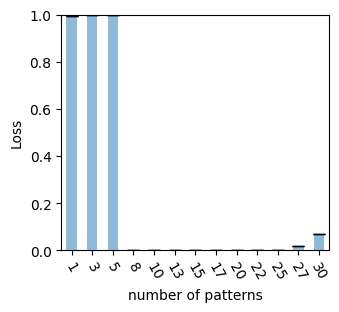

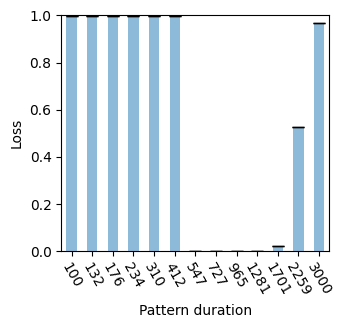

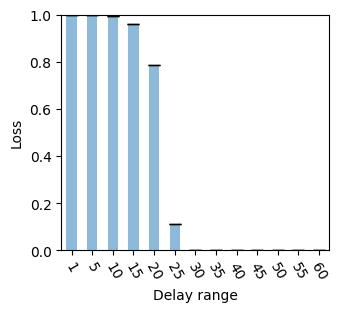

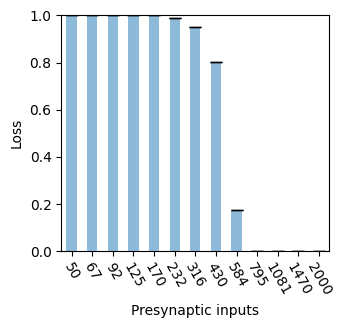

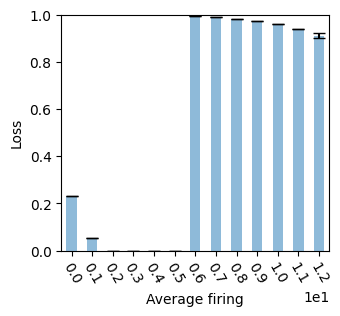

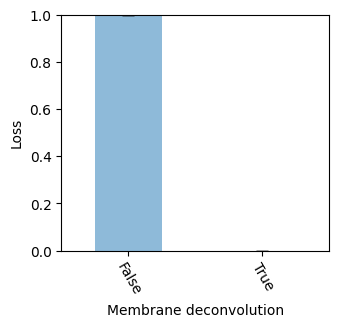

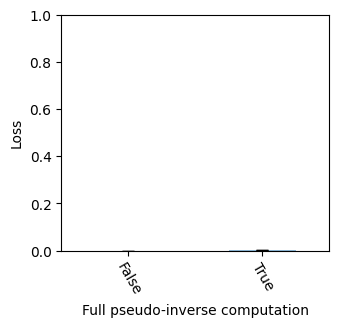

In [6]:
from matplotlib import ticker
subplotpars_scan = SubplotParams(left=0.125, right=.95, bottom=0.25, top=.975)
custom_style = {
    'axes.spines.left': True,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': True,
}

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    print(f'Reading {filename=}...')
    df_scan = pd.read_json(filename)
    print(df_scan)
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html?highlight=errorbar#visualization-errorbars
    fig, ax = plt.subplots(figsize=(opt_scan.fig_width, opt_scan.fig_width), subplotpars=subplotpars_scan)
    gp_scan = df_scan[[key, 'loss']].groupby([key])
    means = gp_scan.mean()
    errors = gp_scan.std()

    with plt.style.context(custom_style):
        means.plot.bar(yerr=errors, ax=ax, capsize=4, rot=-60, legend=False, alpha=.5)

    ax.set_ylabel('Loss')
    ax.set_xlabel(label_dicts[key])

    # ax.set_xscale('logit')
    ax.set_ylim(0, 1)
    if key in ['p_A']:
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.xaxis.get_major_formatter().set_scientific(True)
        ax.xaxis.get_major_formatter().set_powerlimits((0,0))
    #fig = ax.get_figure()
    printfig(fig, 'MNESIS_' + key, fig_height=opt.fig_width/3, fig_width=opt.fig_width/3, figpath=figpath)

    pos = ax.get_position()
    print(pos)
    # plt.show()   # show then close immediately